In [5]:
import sys
sys.path.insert(0, '..')
from dependencies import *


envelopes_log = eelbrain.load.unpickle(PROCESSED_PREDICTOR_DIR / f'~processed_envelopes-log.pickle')
subject_model_predictors = eelbrain.load.unpickle(PREDICTOR_DIR / f'~concatenated_predictors.pickle')
durations = get_durations(envelopes_log)
models = get_models(exclude=['envelope_log_8band', 'envelope_log_onset'])

In [6]:
# Loop over all models
for model in models:
    print(f'\nProcessing universal TRF for model: {model}')
    trf_list = []

    # Collect TRFs for all subjects for this model
    for subject in SUBJECTS:
        trf = eelbrain.load.unpickle(TRF_DIR / subject / f'{subject} decoder-{model}.pickle').h_scaled
        trf_list.append(trf[0])

    # Combine and average across subjects
    universal_trf = eelbrain.combine(trf_list).mean('case')

    # Save universal TRF for this model
    eelbrain.save.pickle(universal_trf, TRF_DIR / f'decoder-universal-trf-{model}.pickle')

    print(f'Saved universal TRF for model {model}')


Processing universal TRF for model: envelope_log
Saved universal TRF for model envelope_log

Processing universal TRF for model: envelope_onset
Saved universal TRF for model envelope_onset


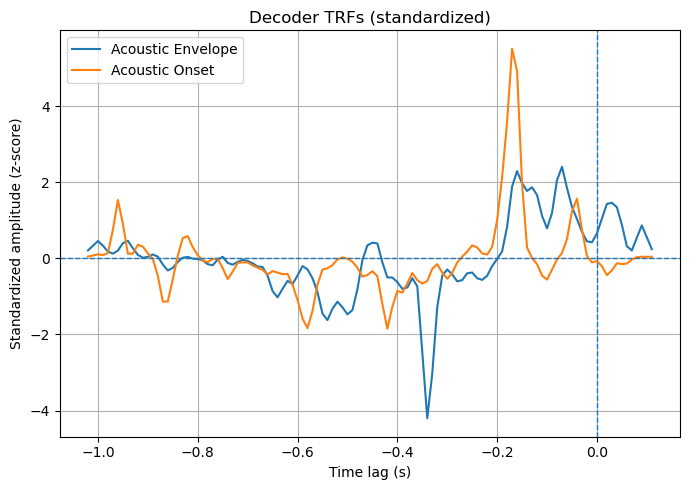

In [10]:
plt.figure(figsize=(7,5))

for model in models:
    # Load TRF
    trf = eelbrain.load.unpickle(TRF_DIR / f'decoder-universal-trf-{model}.pickle')

    # Handle predictors
    if 'predictor' in trf.dims:
        trf_plot = trf.mean('predictor')
    else:
        trf_plot = trf

    # Extract data
    y = trf_plot.x

    # ----------------------------------------
    # Z-score standardization
    # ----------------------------------------
    y_std = (y - np.mean(y)) / np.std(y)

    # Plot
    type_model = 'Acoustic Envelope' if model == 'envelope_log' else 'Acoustic Onset'
    plt.plot(trf_plot.time, y_std, label=type_model)

# ----------------------------------------
# Formatting
# ----------------------------------------
plt.xlabel('Time lag (s)')
plt.ylabel('Standardized amplitude (z-score)')
plt.title('Decoder TRFs (standardized)')
plt.axhline(0, linestyle='--', linewidth=1)
plt.axvline(0, linestyle='--', linewidth=1)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


envelope_log dims: (UTS(-1.02, 0.01, 114),)
envelope_onset dims: (UTS(-1.02, 0.01, 114),)


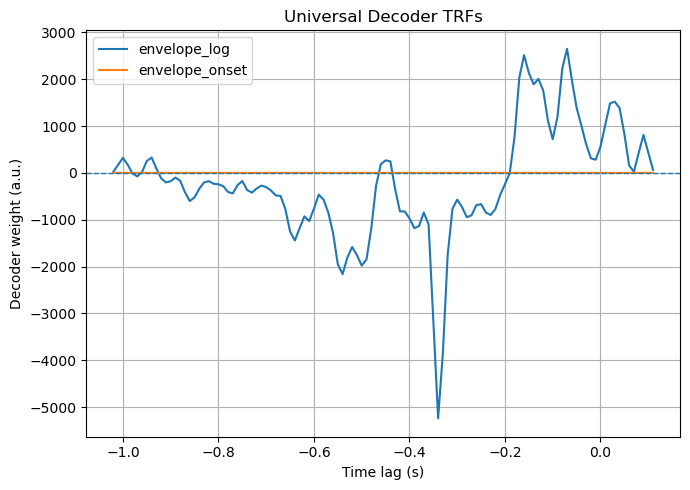

In [7]:
# ------------------------------------------------
# Plot universal decoder TRFs
# ------------------------------------------------
plt.figure(figsize=(7,5))

for model in models:
    # Load TRF
    trf = eelbrain.load.unpickle(TRF_DIR / f'decoder-universal-trf-{model}.pickle')

    print(f"{model} dims:", trf.dims)

    # ----------------------------------------
    # Case 1: multiple predictors
    # ----------------------------------------
    if 'predictor' in trf.dims:
        # Average across predictors (cleanest for thesis figure)
        trf_plot = trf.mean('predictor')
    else:
        trf_plot = trf

    # ----------------------------------------
    # Plot
    # ----------------------------------------
    plt.plot(trf_plot.time, trf_plot.x, label=model)

# ------------------------------------------------
# Formatting
# ------------------------------------------------
plt.xlabel('Time lag (s)')
plt.ylabel('Decoder weight (a.u.)')
plt.title('Universal Decoder TRFs')
plt.axhline(0, linestyle='--', linewidth=1)  # zero line
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
for model in models:
    trf = eelbrain.load.unpickle(TRF_DIR / f'decoder-universal-trf-{model}.pickle')

    # Average across sensors (NOT time)
    trf_mean = trf.mean('predictor')

    # If multiple predictors (optional)
    if 'predictor' in trf_mean.dims:
        trf_mean = trf_mean.mean('predictor')

    # Plot
    plt.figure(figsize=(6,4))
    plt.plot(trf_mean.time, trf_mean.x, label=f'{model}')
    plt.xlabel('Time lag (s)')
    plt.ylabel('TRF amplitude')
    plt.title(f'Universal TRF – {model}')
    plt.grid(True)
    plt.legend()
    plt.show()


KeyError: 'predictor'